# Model Altmana

### Pytania teoretyczne:
Odpowiedzieć na pytanie:


#### Czym jest ryzyko kredytowe?

Ad: Ryzyko kredytowe wynika z możliwości złamania umowy kredytowej przez jedną ze stron. Prostym przykładem może być niewypłacalna osoba / spółka, która zaciągneła kredyt. W takiej sytuacji zazwyczaj bank nie odzyska 100% pożyczonego kapitału, tylko jakąś część albo i nic. To jest to ryzyko kredytowe, ktore na siebie bierze. Ryzyko kredytowe możemy w pewien sposób oszacowywać np. używając wiarygodności kredytowej.
W ramach tego ryzyka wyróżniamy dwa konkretne typy: ryzyko niedotrzymania warunków (default risk) oraz ryzyko wiarygodności kredytowej (creditworthiness risk).

#### Zwięźle omówić ideę liniowej analizy dyskryminacyjnej. Dlaczego można ją wykorzystać do analizy ryzyka kredytowego?

Ad: Głównym zadaniem analizy dyskryminacyjnej jest podzielenie zbioru obiektow na mniejsze podzbiory bazując na naszej wybranej zmiennej objaśnianej. Powstałe grupy mogą nam mówić wtedy z jakiej kategorii jest to obiekt, np czy są "szybkie", "wolne" czy "standardowe" auta, albo lepiej na przykładzie firm, czy ryzyko upadłości jest "duże", "małe", "brak", albo np. czy przekroczenie przez firme przychodzy 100mln jest "mało prawdopodobne", "bardzo prawdopodobne", "trudno zdecydować". Jest to proces przypominający klasteryzację. Można ją wykorzystać do analizy ryzyka kredytowego, gdyż jest to narzędzie ilościowe, czyli narzędzie pozwalające obiektywnie, na podstawie danych historycznych, budować modele prognozowania upadłości firm.

#### Jaką ma postać, do czego służy i jakie ograniczenia ma model Altmana?

Ad: Jest to jeden z najbardziej znanych modeli prognozowania upadłości. Możemy go użyć do dowolnej firmy i na podstawie jego wyniku (wyniku funkcji) próbować szacować, czy dana firma upadnie w przyszłym roku, czy nie, albo czy dana firma będzie wiarygodnym kredytobiorcą, czy też nie.

Model Altmana ma następujący równanie (zmienne są wyjaśnione w dalszej części notebooka):
Z = 1.2 * X1 + 1.4 * X2 + 3.3 * X3 + 0.6 * X4 + 0.99 * X5

Słabymi stronami tego modelu są m.in:
- liniowość (czyli nie uwzględni nieliniowych zależności, droga do bankructwa niekoniecznie musi być liniowa)
- model operuje na danych księgowych (są one dostępne np tylko co kwartał)
- model jest po prostu dość prosty i bazuje na 5 informacjach, co w świecie obecnych finansów nie jest wystarczające
- więcej wad jest podane w dalszej części notebooka

### Zadanie praktyczne:
- Zapoznać się z zamieszczonym na platformie zbiorem danych zawierającym wskaźniki finansowe polskich przedsiębiorstw wraz ze zmienną wskazującą na status upadłości po 1 roku (plik data5year). Opis poszczególnych zmiennych dostępny jest na >> na stronie internetowej <<
- Do dalszej analizy wybrać losowo 100 firm, które upadły i 100, które przetrwały kolejny rok działalności.
- Wykorzystać oryginalny model Altmana do predykcji upadłości przedsiębiorstw. Ocenić jakość tej predykcji (porównać uzyskane wyniki z rzeczywistą informacją o upadłości tych firm). 
- Odpowiedzieć na pytanie, czy oryginalny model jest skutecznym narzędziem do predykcji upadłości firm w przypadku rozważanych danych? Proszę o próbę wyjaśnienia dlaczego tak jest.

Zmienne do modelu (w nawiasie zmienne z pliku):
- X1 = Working capital/Total assets (X3)
- X2 = Retained Earnings/Total assets (X6)
- X3 = Earnings before interest and taxes/Total assets (X7)
- X4 = Market value equity/Book value of total debt (X8)
- X5 = Sales/Total assets (X9)

Model Altmana
Z = 1.2 * X1 + 1.4 * X2 + 3.3 * X3 + 0.6 * X4 + 0.99 * X5

- Z < 1.8: bankructwo
- 1.8 < Z < 3.0: szara strefa
- Z > 3.0$: bankructwo mało prawdopodobne (firma przetrwa) 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

df = pd.read_csv('csv_result-5year.csv', na_values='?')

print(f"Rozmiar danych: {df.shape}")
print(f"Rozkład klas określającej upadłość:\n{df['class'].value_counts().rename({0: '0 (przetrwała)', 1: '1 (upadła)'})}")
print()
print(f"Brakujące wartości w kluczowych kolumnach (naszych zmiennych X):")
for col in ['Attr3', 'Attr6', 'Attr7', 'Attr8', 'Attr9']:
    missing = df[col].isna().sum()
    print(f"{col}: brakuje {missing} ({missing/len(df)*100:.1f}%)")

Rozmiar danych: (5910, 66)
Rozkład klas określającej upadłość:
class
0 (przetrwała)    5500
1 (upadła)         410
Name: count, dtype: int64

Brakujące wartości w kluczowych kolumnach (naszych zmiennych X):
Attr3: brakuje 3 (0.1%)
Attr6: brakuje 3 (0.1%)
Attr7: brakuje 3 (0.1%)
Attr8: brakuje 18 (0.3%)
Attr9: brakuje 1 (0.0%)


In [2]:
# Losujemy zbiór 100 firm upadłych i 100 firm które przetrwały
np.random.seed(42)

bankrupt = df[df['class'] == 1].sample(n=100, random_state=42)
survived = df[df['class'] == 0].sample(n=100, random_state=42)

sample = pd.concat([bankrupt, survived], ignore_index=True)
print(f"Próbka (łącznie): {sample.shape[0]} firm")
print(f"Upadłe: {(sample['class'] == 1).sum()}, Przetrwały: {(sample['class'] == 0).sum()}")

Próbka (łącznie): 200 firm
Upadłe: 100, Przetrwały: 100


In [3]:
# Przygotowuję zmienne i obliczam Z-score
altman_cols = ['Attr3', 'Attr6', 'Attr7', 'Attr8', 'Attr9']

# Pamiętam, że w danych mogą być brakujące wartości, więc sprawdzam ile ich jest w próbce i usuwam je
missing_before = sample[altman_cols].isna().sum()
print("Brakujące wartości w próbce (przed usunięciem):")
print(missing_before[missing_before > 0])

# Usuwam wspomniane wiersze
sample_clean = sample.dropna(subset=altman_cols).copy()
print()
print(f"Usunięto {len(sample) - len(sample_clean)} wierszy z brakującymi danymi")
print(f"Pozostało {len(sample_clean)} firm (upadłe: {(sample_clean['class']==1).sum()}, przetrwały: {(sample_clean['class']==0).sum()})")

# Obliczam Z-score Altmana
# Z = 1.2*X1 + 1.4*X2 + 3.3*X3 + 0.6*X4 + 0.99*X5
sample_clean['Z_score'] = (
    1.2  * sample_clean['Attr3'] +  # X1: Working capital / Total assets
    1.4  * sample_clean['Attr6'] +  # X2: Retained Earnings / Total assets
    3.3  * sample_clean['Attr7'] +  # X3: EBIT / Total assets
    0.6  * sample_clean['Attr8'] +  # X4: Market value equity / Book value of total debt
    0.99 * sample_clean['Attr9']    # X5: Sales / Total assets
)

# Klasyfikuję na podstawie Z-score
sample_clean['prediction'] = np.where(
    sample_clean['Z_score'] > 3.0, 0,       # bankructwo mało prawdopodobne
    np.where(sample_clean['Z_score'] < 1.8, 1, -1)  # bankructwo / szara strefa
)

# Statystyki Z-score
print(f"Statystyki Z-score:")
print(sample_clean.groupby('class')['Z_score'].describe().round(3))

print()
print(f"Rozkład predykcji:")
pred_labels = {0: 'Przetrwa (Z>3)', 1: 'Bankrut (Z<1.8)', -1: 'Szara strefa (1.8-3.0)'}
for cls in [1, -1, 0]:
    count = (sample_clean['prediction'] == cls).sum()
    print(f"  {pred_labels[cls]}: {count}")

Brakujące wartości w próbce (przed usunięciem):
Attr3    1
Attr6    1
Attr7    1
Attr8    3
dtype: int64

Usunięto 4 wierszy z brakującymi danymi
Pozostało 196 firm (upadłe: 99, przetrwały: 97)
Statystyki Z-score:
       count   mean     std     min    25%    50%    75%     max
class                                                           
0       97.0  3.453   3.846  -4.270  1.841  2.788  3.939  31.641
1       99.0  2.167  10.679 -14.336  0.535  1.577  3.145  99.247

Rozkład predykcji:
  Bankrut (Z<1.8): 76
  Szara strefa (1.8-3.0): 48
  Przetrwa (Z>3): 72


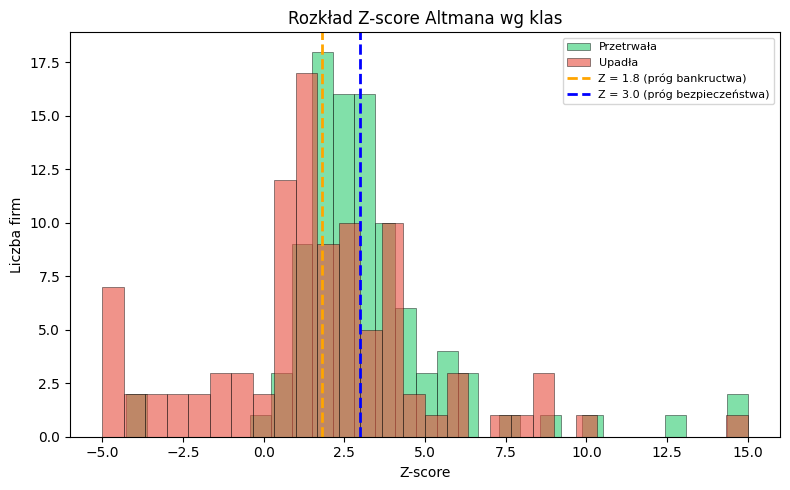

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {0: '#2ecc71', 1: '#e74c3c'}
labels = {0: 'Przetrwała', 1: 'Upadła'}

for cls in [0, 1]:
    data = sample_clean[sample_clean['class'] == cls]['Z_score'].clip(-5, 15)
    ax.hist(data, bins=30, alpha=0.6, color=colors[cls], label=labels[cls], edgecolor='black', linewidth=0.5)

ax.axvline(x=1.8, color='orange', linestyle='--', linewidth=2, label='Z = 1.8 (próg bankructwa)')
ax.axvline(x=3.0, color='blue', linestyle='--', linewidth=2, label='Z = 3.0 (próg bezpieczeństwa)')
ax.set_xlabel('Z-score')
ax.set_ylabel('Liczba firm')
ax.set_title('Rozkład Z-score Altmana wg klas')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Firmy z jednoznaczną klasyfikacją: 148 / 196 (odrzucono 48 z szarej strefy)


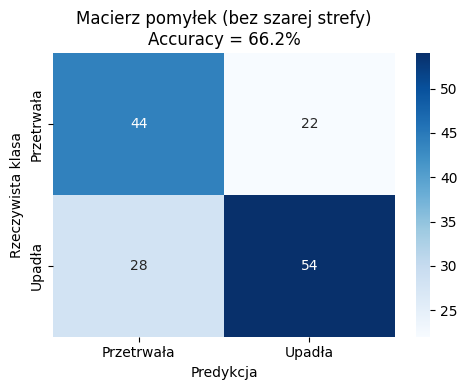

In [8]:
# Tworzę macierz pomyłek 2x2 (bez szarej strefy)
# Odrzucam firmy z szarej strefy (1.8 < Z < 3.0), zostają tylko jednoznaczne klasyfikacje
sample_no_grey = sample_clean[sample_clean['prediction'] != -1].copy()
print(f"Firmy z jednoznaczną klasyfikacją: {len(sample_no_grey)} / {len(sample_clean)} (odrzucono {len(sample_clean) - len(sample_no_grey)} z szarej strefy)")

y_true = sample_no_grey['class'].values
y_pred = sample_no_grey['prediction'].values

# Macierz pomyłek
cm = confusion_matrix(y_true, y_pred)
# print()
# print("Macierz pomyłek:")
# print(pd.DataFrame(cm, index=['Rzeczywiste: Przetrwała', 'Rzeczywiste: Upadła'], columns=['Predykcja: Przetrwała', 'Predykcja: Upadła']))

# # Accuracy
# acc = (cm[0, 0] + cm[1, 1]) / cm.sum()
# print()
# print(f"Accuracy: {acc:.4f} ({acc*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Przetrwała', 'Upadła'],
            yticklabels=['Przetrwała', 'Upadła'])
ax.set_xlabel('Predykcja')
ax.set_ylabel('Rzeczywista klasa')
ax.set_title(f'Macierz pomyłek (bez szarej strefy)\nAccuracy = {acc:.1%}')
plt.tight_layout()
plt.show()

## Podsumowanie i wnioski

### Czy oryginalny model Altmana jest skutecznym narzędziem do predykcji upadłości firm w przypadku rozważanych danych?

Na podstawie przeprowadzonej analizy można stwierdzić, że oryginalny model Z-score Altmana **ma ograniczoną skuteczność** w predykcji upadłości polskich przedsiębiorstw. Głównymi przyczynami mogą być:

1. Model został zbudowany na danych firm amerykańskich z lat 1946-1965. Polskie firmy działają w zupełnie innym otoczeniu gospodarczym, prawnym i regulacyjnym, co wpływa na wartości wskaźników finansowych.

2. Model został wytrenowany na podobnych firmach z określonej kategorii. Mogą być one zupełnie innego typu spółki niż te z naszego zbioru.

3. Zmienna X4 (Market value equity / Book value of total debt). Oryginalny model Altmana wykorzystuje wartość rynkową kapitału własnego, natomiast w analizowanym zbiorze danych (Attr8) dostępna jest jedynie wartość księgowa. Dla firm nienotowanych na giełdzie (a większość polskich firm to firmy niepubliczne) wartość rynkowa nie jest bezpośrednio dostępna, co może wpływać na wynik Z-score.

4. Różnice w systemach rachunkowości. Polskie standardy rachunkowości i Międzynarodowe Standardy Sprawozdawczości Finansowej mogą się różnić od tych stosowanych w USA, co wpływa na sposób kalkulacji poszczególnych wskaźników finansowych.

5. Model jest liniowy. Jak wskazano na wykładzie, droga do bankructwa niekoniecznie musi mieć charakter liniowy. Nieliniowe zależności między wskaźnikami a ryzykiem upadłości nie są uwzględniane.

6. Model bazuje na niewielkiej liczbie zmiennych (5 wskaźników). Współczesne modele predykcji upadłości wykorzystują znacznie więcej zmiennych, co pozwala na lepsze uchwycenie złożoności sytuacji finansowej przedsiębiorstwa.

7. Progi decyzyjne (1.8 i 3.0) zostały wyznaczone na podstawie danych firm amerykańskich i mogą nie być adekwatne dla polskiego rynku.

## Liniowa Analiza Dyskryminacyjna (LDA)

Buduję własny model LDA na wszystkich 64 zmiennych (Attr1-Attr64). Model trenuję na pozostałych firmach ze zbioru (tych, które nie zostały wylosowane do naszej próbki 200), a testuję na naszych 200 firmach, cyzli tak jak dla modelu Altmana, którego współczynniki też zostały wyznaczone na innych danych.

Także zanim zbuduję model, to filtruje dane z braków, czyli zostawiam wiersze, które mają wszystkie potrzbne nam kolumny.

In [6]:
# Buduję model LDA na wszystkich zmiennych (Attr1-Attr64)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

all_attrs = [f'Attr{i}' for i in range(1, 65)]

# Firmy spoza naszej próbki 200
train_ids = df.index.difference(pd.concat([bankrupt, survived]).index)
df_train = df.loc[train_ids].dropna(subset=all_attrs).copy()
print(f"Zbiór treningowy: {len(df_train)} firm (upadłe: {(df_train['class']==1).sum()}, przetrwały: {(df_train['class']==0).sum()})")

# Nasze 200 wylosowanych firm
df_test = sample.dropna(subset=all_attrs).copy()
print(f"Zbiór testowy: {len(df_test)} firm (upadłe: {(df_test['class']==1).sum()}, przetrwały: {(df_test['class']==0).sum()})")

# LDA
X_train = df_train[all_attrs].values
y_train = df_train['class'].values

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

X_test = df_test[all_attrs].values
y_test = df_test['class'].values

Zbiór treningowy: 2953 firm (upadłe: 75, przetrwały: 2878)
Zbiór testowy: 78 firm (upadłe: 27, przetrwały: 51)


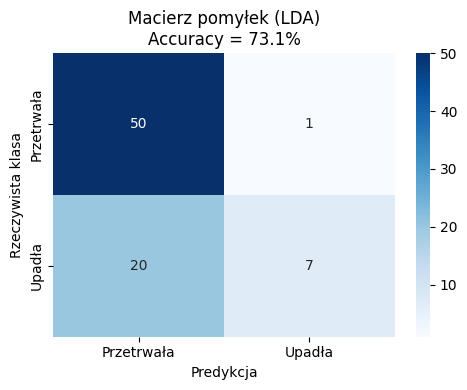


Porównanie:
Altman accuracy = 66.2%
LDA accuracy = 73.1%


In [7]:
# Predykcja i ocena jakości LDA na zbiorze testowym (nasze 200 firm)
y_pred_lda = lda.predict(X_test)

cm_lda = confusion_matrix(y_test, y_pred_lda)
acc_lda = (cm_lda[0, 0] + cm_lda[1, 1]) / cm_lda.sum()

# print(f"Macierz pomyłek (LDA):")
# print(pd.DataFrame(cm_lda, index=['Rzeczywiste: Przetrwała', 'Rzeczywiste: Upadła'], columns=['Predykcja: Przetrwała', 'Predykcja: Upadła']))
# print(f"\nAccuracy: {acc_lda:.4f} ({acc_lda*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Przetrwała', 'Upadła'],
            yticklabels=['Przetrwała', 'Upadła'])
ax.set_xlabel('Predykcja')
ax.set_ylabel('Rzeczywista klasa')
ax.set_title(f'Macierz pomyłek (LDA)\nAccuracy = {acc_lda:.1%}')
plt.tight_layout()
plt.show()

print()
print(f"Porównanie:")
print(f"Altman accuracy = {acc:.1%}")
print(f"LDA accuracy = {acc_lda:.1%}")

## Wyniki modeli (accuracy)

Altman accuracy: 66.2%
LDA accuracy: 73.1%

Wyniki wskazują, że nasz nowy model utworzony za pmocą LDA jest lepszy niż model Altmana.
Myślę, że nie jest to nic zaskakującego, a raczej spodziewanego. Powody tego zostały już wymienione wyżej w naszej analizie, w skrócie są to m.in.:

1. Model został zbudowany na danych firm amerykańskich.

2. Model został wytrenowany na podobnych firmach z określonej kategorii.

3. Zmienna X4 (Market value equity / Book value of total debt).

4. Różnice w systemach rachunkowości.

5. Model jest liniowy.

6. Model bazuje na niewielkiej liczbie zmiennych (5 wskaźników).

7. Progi decyzyjne (1.8 i 3.0).